In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('house_price_dataset_india_12k_updated.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col:30s} | dtype: {df[col].dtype} | nulls: {df[col].isnull().sum()} | unique: {df[col].nunique()}")

Shape: (12000, 34)

Columns (34):
   1. House_ID                       | dtype: int64 | nulls: 0 | unique: 12000
   2. City                           | dtype: object | nulls: 0 | unique: 5
   3. Locality_Tier                  | dtype: object | nulls: 0 | unique: 3
   4. BHK                            | dtype: int64 | nulls: 0 | unique: 5
   5. Bathrooms                      | dtype: int64 | nulls: 0 | unique: 7
   6. Super_Area_sqft                | dtype: float64 | nulls: 0 | unique: 7563
   7. Carpet_Area_sqft               | dtype: float64 | nulls: 0 | unique: 6854
   8. Floor_No                       | dtype: int64 | nulls: 0 | unique: 33
   9. Total_Floors                   | dtype: int64 | nulls: 0 | unique: 35
  10. Property_Age_years             | dtype: int64 | nulls: 0 | unique: 33
  11. Parking                        | dtype: int64 | nulls: 0 | unique: 2
  12. Furnishing                     | dtype: object | nulls: 0 | unique: 3
  13. Lift                           | dtype: 

In [3]:
# =============================================
# STEP 1: BASIC INSPECTION & MISSING VALUES
# =============================================
print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")

BASIC STATISTICS
          House_ID           BHK     Bathrooms  Super_Area_sqft  \
count  12000.00000  12000.000000  12000.000000     12000.000000   
mean    6000.50000      2.304167      2.536083      1018.260342   
std     3464.24595      0.934909      1.102482       379.974189   
min        1.00000      1.000000      1.000000       350.000000   
25%     3000.75000      2.000000      2.000000       781.800000   
50%     6000.50000      2.000000      2.000000       950.500000   
75%     9000.25000      3.000000      3.000000      1226.300000   
max    12000.00000      5.000000      7.000000      3010.400000   

       Carpet_Area_sqft      Floor_No  Total_Floors  Property_Age_years  \
count      12000.000000  12000.000000  12000.000000        12000.000000   
mean         763.563383      7.599000     15.232667            8.615917   
std          291.095491      5.685352      5.707604            5.374815   
min          250.000000      0.000000      3.000000            0.000000   
25% 

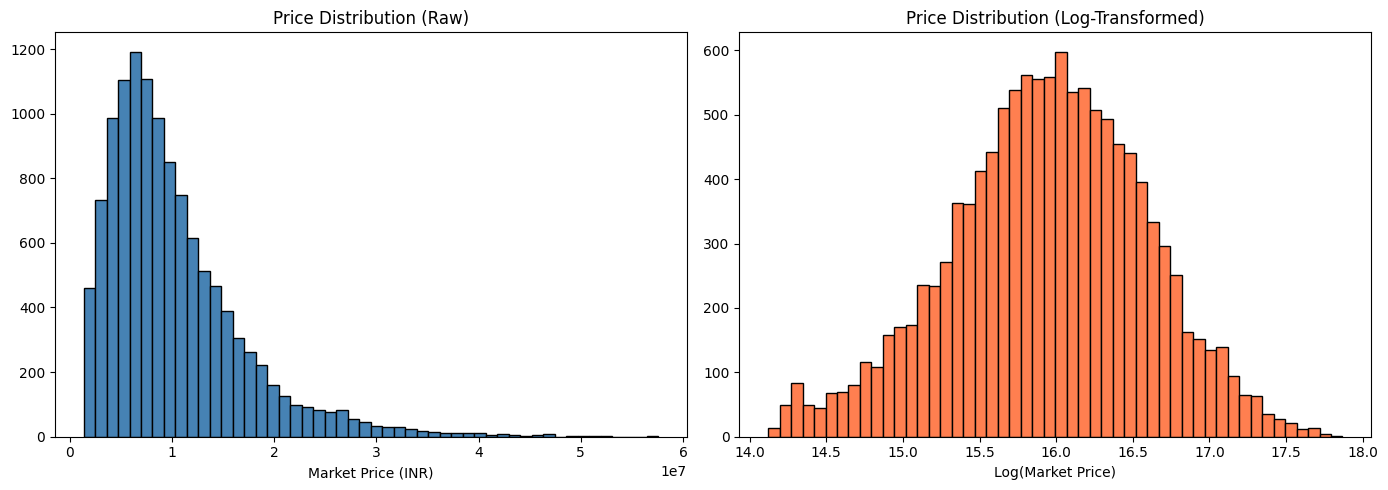

Skewness (raw):  1.714
Skewness (log):  -0.189
Kurtosis (raw):  4.317
Kurtosis (log):  -0.081


In [4]:
# =============================================
# STEP 2: TARGET VARIABLE ANALYSIS
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Market_Price_INR'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Market Price (INR)')

axes[1].hist(np.log1p(df['Market_Price_INR']), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Price Distribution (Log-Transformed)')
axes[1].set_xlabel('Log(Market Price)')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness (raw):  {df['Market_Price_INR'].skew():.3f}")
print(f"Skewness (log):  {np.log1p(df['Market_Price_INR']).skew():.3f}")
print(f"Kurtosis (raw):  {df['Market_Price_INR'].kurtosis():.3f}")
print(f"Kurtosis (log):  {np.log1p(df['Market_Price_INR']).kurtosis():.3f}")

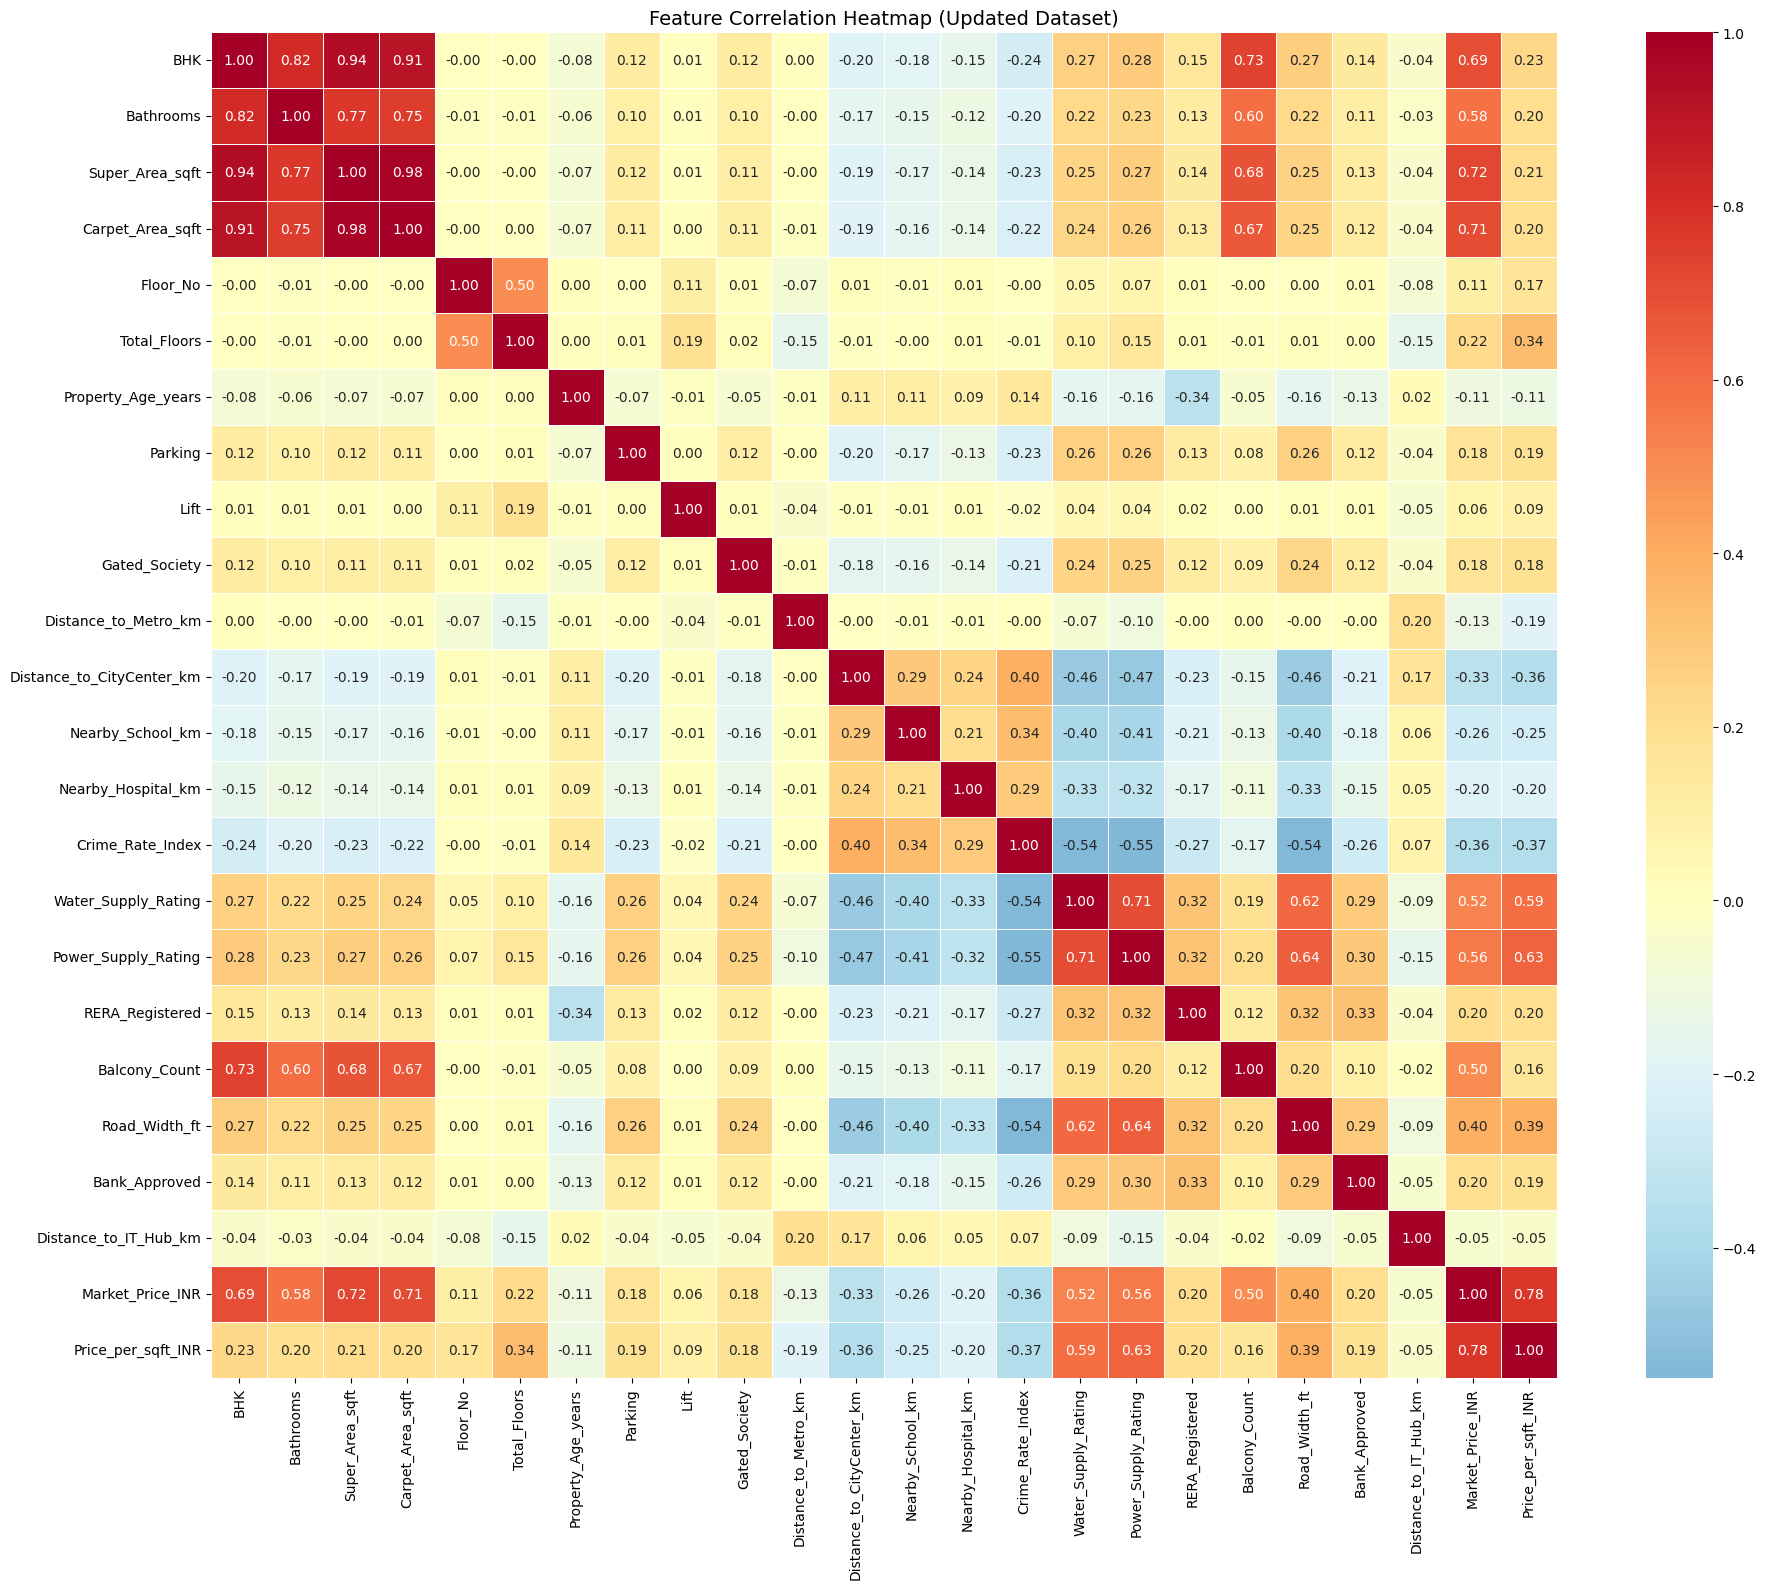


Top correlations with Market_Price_INR:
Market_Price_INR             1.000000
Price_per_sqft_INR           0.777605
Super_Area_sqft              0.723853
Carpet_Area_sqft             0.705184
BHK                          0.693469
Bathrooms                    0.576934
Power_Supply_Rating          0.562593
Water_Supply_Rating          0.523834
Balcony_Count                0.502673
Road_Width_ft                0.399125
Total_Floors                 0.222253
RERA_Registered              0.203348
Bank_Approved                0.197490
Parking                      0.180189
Gated_Society                0.178579
Floor_No                     0.108962
Lift                         0.062801
Distance_to_IT_Hub_km       -0.047894
Property_Age_years          -0.112751
Distance_to_Metro_km        -0.130505
Nearby_Hospital_km          -0.204064
Nearby_School_km            -0.259725
Distance_to_CityCenter_km   -0.332494
Crime_Rate_Index            -0.363716


In [5]:
# =============================================
# STEP 3: CORRELATION HEATMAP (Numerical features)
# =============================================
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('House_ID')

plt.figure(figsize=(20, 16))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap (Updated Dataset)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = correlation_matrix['Market_Price_INR'].sort_values(ascending=False)
print("\nTop correlations with Market_Price_INR:")
print(target_corr.to_string())

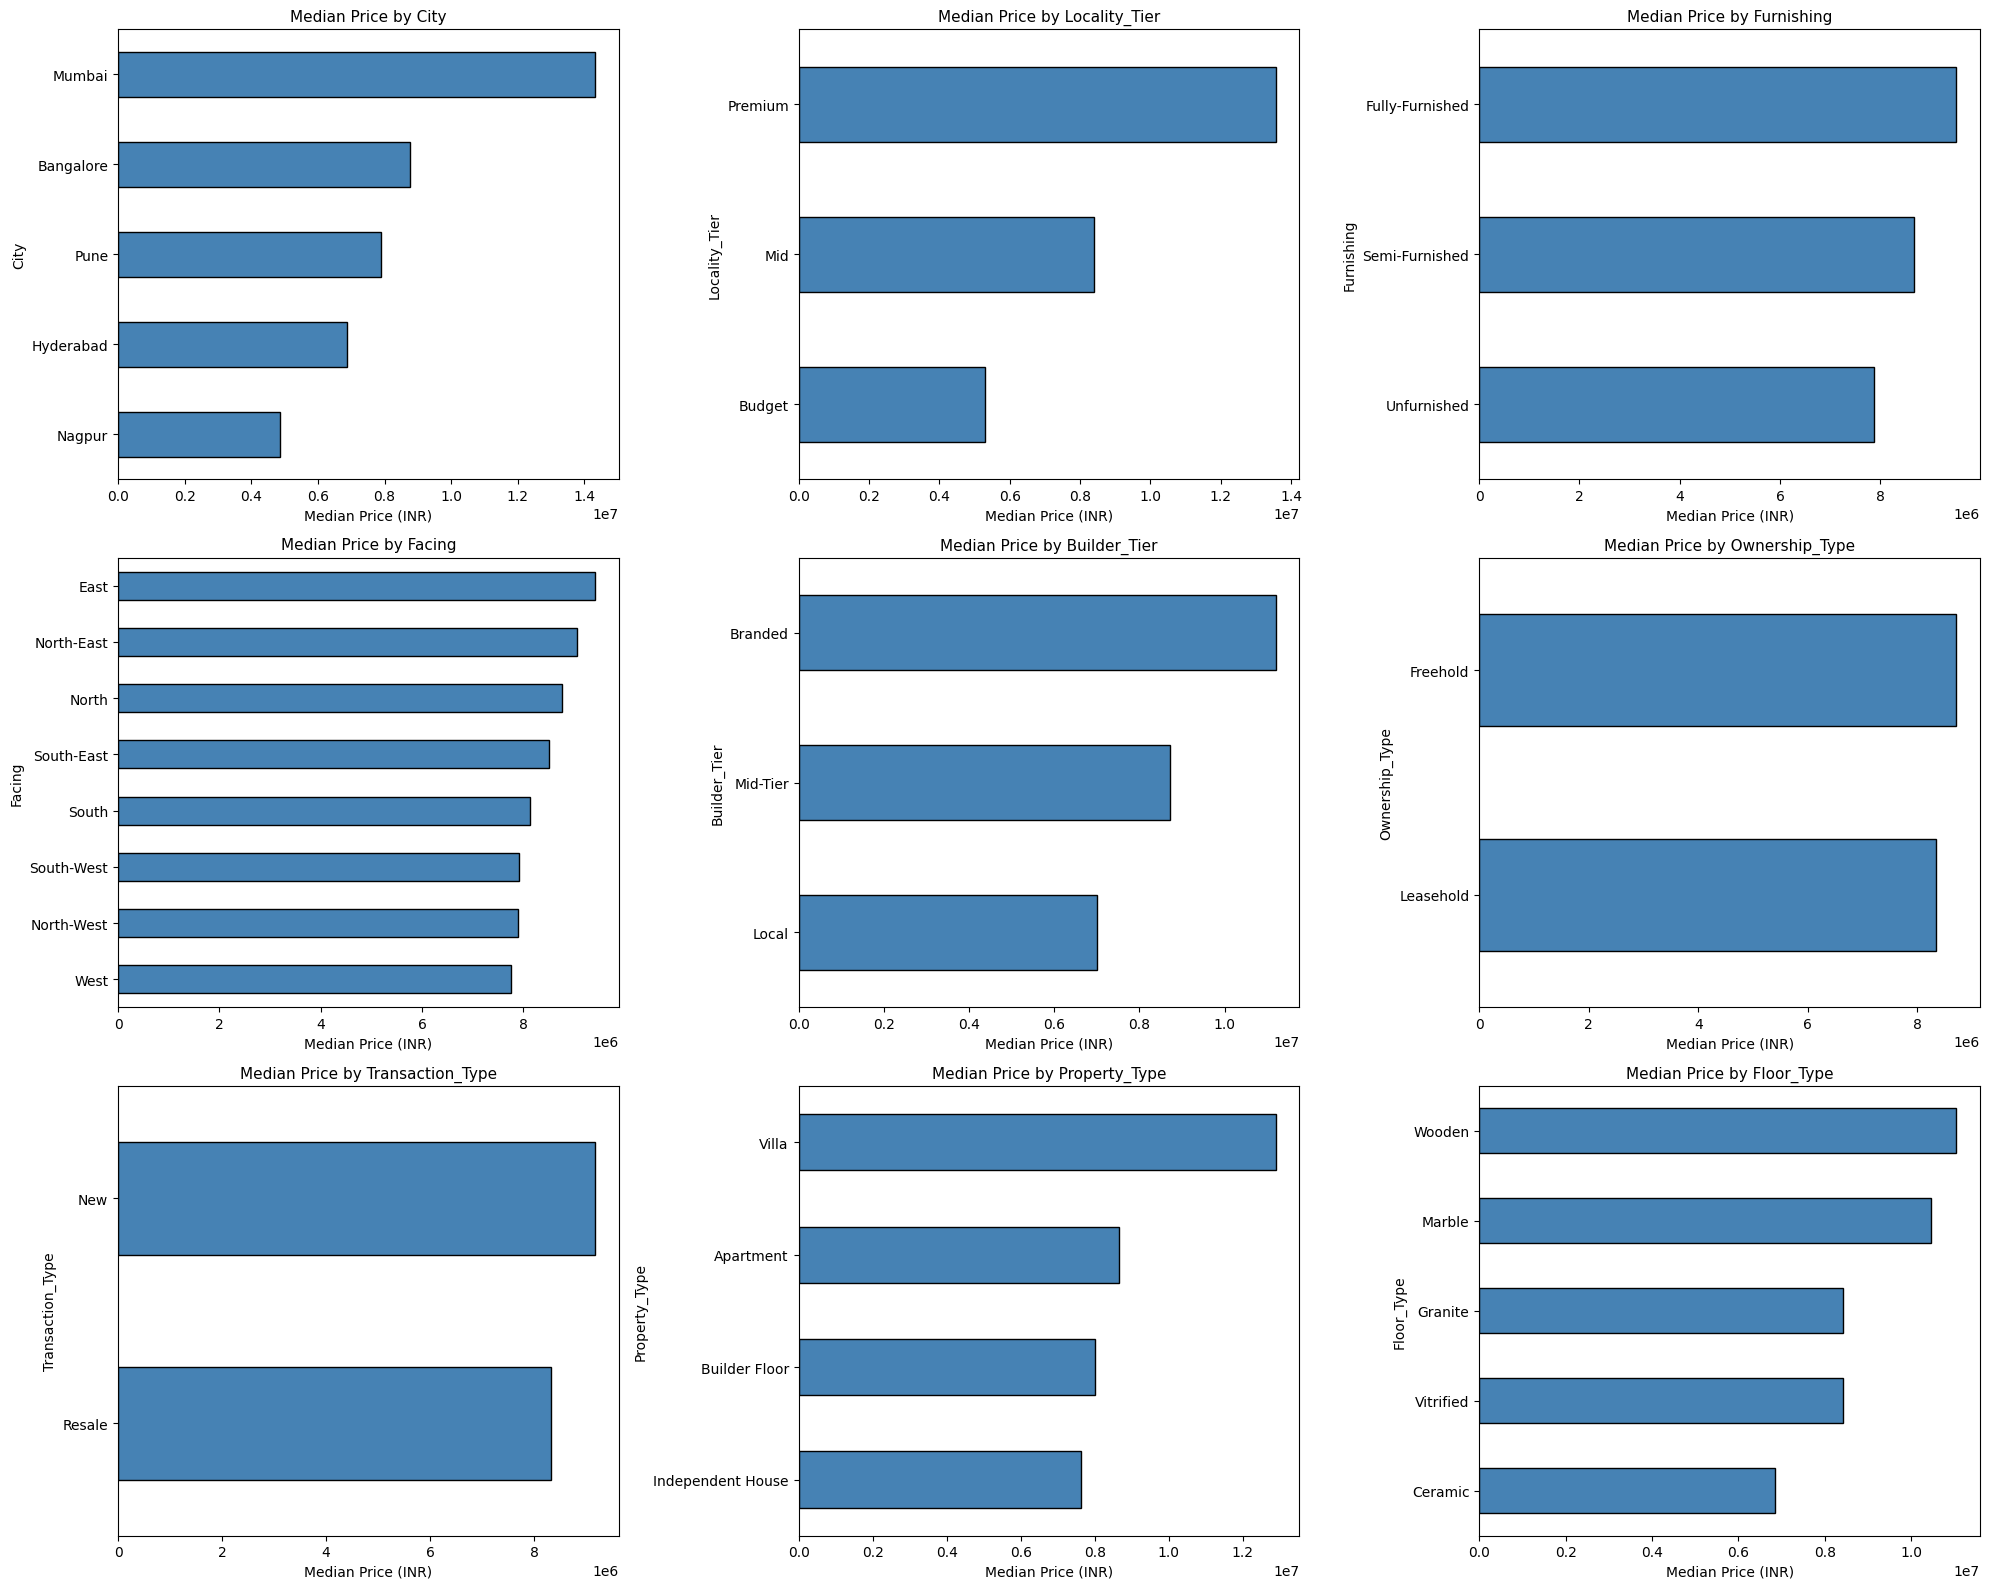

In [6]:
# =============================================
# STEP 4: CATEGORICAL FEATURE ANALYSIS
# =============================================
cat_cols = ['City', 'Locality_Tier', 'Furnishing', 'Facing', 'Builder_Tier', 
            'Ownership_Type', 'Transaction_Type', 'Property_Type', 'Floor_Type']

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    median_price = df.groupby(col)['Market_Price_INR'].median().sort_values()
    median_price.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Median Price by {col}', fontsize=11)
    axes[i].set_xlabel('Median Price (INR)')

plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# =============================================
# STEP 5: DROP LEAKY / USELESS COLUMNS
# =============================================
# House_ID: no predictive value
# Price_per_sqft_INR: derived from target (data leakage)

df_model = df.drop(columns=['House_ID', 'Price_per_sqft_INR'])
print(f"After dropping ID and leaky column: {df_model.shape}")

After dropping ID and leaky column: (12000, 32)


In [8]:
# =============================================
# STEP 6: FEATURE ENGINEERING
# =============================================

# 6a. Area efficiency ratio
df_model['Area_Ratio'] = df_model['Carpet_Area_sqft'] / df_model['Super_Area_sqft']

# 6b. Total proximity score (lower = better location)
df_model['Total_Proximity_Score'] = (
    df_model['Distance_to_Metro_km'] + 
    df_model['Distance_to_CityCenter_km'] + 
    df_model['Nearby_School_km'] + 
    df_model['Nearby_Hospital_km'] +
    df_model['Distance_to_IT_Hub_km']
)

# 6c. Amenity score (composite of binary amenities)
df_model['Amenity_Score'] = (
    df_model['Parking'] + 
    df_model['Lift'] + 
    df_model['Gated_Society'] +
    df_model['RERA_Registered'] +
    df_model['Bank_Approved']
)

# 6d. Floor position ratio
df_model['Floor_Ratio'] = df_model['Floor_No'] / (df_model['Total_Floors'] + 1)

# 6e. Infrastructure score (water + power)
df_model['Infrastructure_Score'] = (df_model['Water_Supply_Rating'] + df_model['Power_Supply_Rating']) / 2

# 6f. BHK density (rooms per sqft - indicates space utilization)
df_model['BHK_Density'] = df_model['BHK'] / df_model['Super_Area_sqft']

# 6g. Bathroom-to-BHK ratio
df_model['Bath_BHK_Ratio'] = df_model['Bathrooms'] / df_model['BHK']

# 6h. Safety-accessibility trade-off
df_model['Safety_Access_Score'] = (100 - df_model['Crime_Rate_Index']) / (df_model['Distance_to_CityCenter_km'] + 1)

print("Engineered features added:")
new_feats = ['Area_Ratio', 'Total_Proximity_Score', 'Amenity_Score', 'Floor_Ratio',
             'Infrastructure_Score', 'BHK_Density', 'Bath_BHK_Ratio', 'Safety_Access_Score']
print(df_model[new_feats].describe().round(3).to_string())
print(f"\nShape after feature engineering: {df_model.shape}")

Engineered features added:
       Area_Ratio  Total_Proximity_Score  Amenity_Score  Floor_Ratio  Infrastructure_Score  BHK_Density  Bath_BHK_Ratio  Safety_Access_Score
count   12000.000              12000.000      12000.000    12000.000             12000.000    12000.000       12000.000            12000.000
mean        0.750                 37.004          3.436        0.461                 6.650        0.002           1.132                6.652
std         0.058                 11.511          1.197        0.286                 1.536        0.000           0.350                8.983
min         0.650                  4.180          0.000        0.000                 2.300        0.001           0.333                0.563
25%         0.700                 28.947          3.000        0.217                 5.500        0.002           1.000                2.592
50%         0.750                 36.720          4.000        0.462                 6.600        0.002           1.000        

In [9]:
# =============================================
# STEP 7: ENCODE CATEGORICAL VARIABLES
# =============================================
from sklearn.preprocessing import LabelEncoder

# Identify all categorical columns
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode ({len(categorical_cols)}): {categorical_cols}")

# One-hot encode all categorical features
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Convert boolean columns to int
bool_cols = df_model.select_dtypes(include=['bool']).columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f"\nShape after encoding: {df_model.shape}")
print(f"All columns are numeric: {df_model.select_dtypes(include=[np.number]).shape[1] == df_model.shape[1]}")

Categorical columns to encode (9): ['City', 'Locality_Tier', 'Furnishing', 'Facing', 'Builder_Tier', 'Ownership_Type', 'Transaction_Type', 'Property_Type', 'Floor_Type']

Shape after encoding: (12000, 57)
All columns are numeric: True


In [10]:
# =============================================
# STEP 8: OUTLIER REMOVAL + LOG TRANSFORM TARGET
# =============================================

# Log-transform target
df_model['Log_Price'] = np.log1p(df_model['Market_Price_INR'])

# Remove extreme outliers (1st and 99th percentile)
Q1 = df_model['Market_Price_INR'].quantile(0.01)
Q99 = df_model['Market_Price_INR'].quantile(0.99)
before = len(df_model)
df_model = df_model[(df_model['Market_Price_INR'] >= Q1) & (df_model['Market_Price_INR'] <= Q99)]
after = len(df_model)

print(f"Outlier removal: {before} -> {after} rows (removed {before - after})")
print(f"Price range: INR {df_model['Market_Price_INR'].min():,.0f} - INR {df_model['Market_Price_INR'].max():,.0f}")

Outlier removal: 12000 -> 11760 rows (removed 240)
Price range: INR 1,647,011 - INR 33,911,652


In [11]:
# =============================================
# STEP 9: TRAIN-TEST SPLIT
# =============================================
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Market_Price_INR', 'Log_Price'])
y = df_model['Log_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"Features:  {X_train.shape[1]}")

Train set: (9408, 56)
Test set:  (2352, 56)
Features:  56


In [12]:
# =============================================
# STEP 10: FEATURE SCALING
# =============================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_features = X_train.select_dtypes(include=[np.number]).columns

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("Scaling complete.")
print(f"\nSample scaled means (should be ~0): {X_train_scaled[numerical_features[:5]].mean().round(4).to_dict()}")
print(f"Sample scaled stds  (should be ~1): {X_train_scaled[numerical_features[:5]].std().round(4).to_dict()}")

Scaling complete.

Sample scaled means (should be ~0): {'BHK': -0.0, 'Bathrooms': -0.0, 'Super_Area_sqft': -0.0, 'Carpet_Area_sqft': -0.0, 'Floor_No': -0.0}
Sample scaled stds  (should be ~1): {'BHK': 1.0001, 'Bathrooms': 1.0001, 'Super_Area_sqft': 1.0001, 'Carpet_Area_sqft': 1.0001, 'Floor_No': 1.0001}


In [13]:
# =============================================
# STEP 11: PREPROCESSING SUMMARY
# =============================================
print("=" * 60)
print("PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)
print(f"""
1. Loaded updated dataset:          12,000 rows x 34 columns
2. Dropped leaky/useless cols:      House_ID, Price_per_sqft_INR
3. Feature engineering (8 new):     Area_Ratio, Total_Proximity_Score,
                                    Amenity_Score, Floor_Ratio,
                                    Infrastructure_Score, BHK_Density,
                                    Bath_BHK_Ratio, Safety_Access_Score
4. One-hot encoded categoricals:    City, Locality_Tier, Furnishing,
                                    Facing, Builder_Tier, Ownership_Type,
                                    Transaction_Type, Property_Type, Floor_Type
5. Outlier removal (1st-99th %ile): {X_train.shape[0] + X_test.shape[0]} rows retained
6. Log-transformed target:          Log(Market_Price_INR)
7. Train/Test split:                80/20
8. StandardScaler on numerics:      Applied

Final feature count:                {X_train.shape[1]}
Training samples:                   {X_train.shape[0]}
Test samples:                       {X_test.shape[0]}
""")

print("Feature list:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")

PREPROCESSING PIPELINE SUMMARY

1. Loaded updated dataset:          12,000 rows x 34 columns
2. Dropped leaky/useless cols:      House_ID, Price_per_sqft_INR
3. Feature engineering (8 new):     Area_Ratio, Total_Proximity_Score,
                                    Amenity_Score, Floor_Ratio,
                                    Infrastructure_Score, BHK_Density,
                                    Bath_BHK_Ratio, Safety_Access_Score
4. One-hot encoded categoricals:    City, Locality_Tier, Furnishing,
                                    Facing, Builder_Tier, Ownership_Type,
                                    Transaction_Type, Property_Type, Floor_Type
5. Outlier removal (1st-99th %ile): 11760 rows retained
6. Log-transformed target:          Log(Market_Price_INR)
7. Train/Test split:                80/20
8. StandardScaler on numerics:      Applied

Final feature count:                56
Training samples:                   9408
Test samples:                       2352

Feature list:
   1

In [14]:
# =============================================
# STEP 12: MODEL TRAINING & COMPARISON
# =============================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    start = time.time()
    
    # Use scaled data for linear models, raw for tree-based
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    train_time = time.time() - start
    
    # Convert back from log scale for interpretable metrics
    y_pred_actual = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'Train_Time': train_time
    }
    
    print(f"{name:25s} | R2: {r2:.4f} | RMSE: Rs.{rmse:,.0f} | MAE: Rs.{mae:,.0f} | MAPE: {mape:.2f}% | Time: {train_time:.2f}s")

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print("\nModel Comparison (sorted by R2):")
print(results_df.to_string())

Linear Regression         | R2: 0.8889 | RMSE: Rs.1,936,050 | MAE: Rs.985,493 | MAPE: 9.70% | Time: 0.02s
Ridge Regression          | R2: 0.8892 | RMSE: Rs.1,933,114 | MAE: Rs.985,666 | MAPE: 9.71% | Time: 0.01s
Lasso Regression          | R2: 0.8989 | RMSE: Rs.1,846,206 | MAE: Rs.993,254 | MAPE: 9.82% | Time: 0.04s
Random Forest             | R2: 0.9806 | RMSE: Rs.809,584 | MAE: Rs.603,549 | MAPE: 6.53% | Time: 2.81s
Gradient Boosting         | R2: 0.9818 | RMSE: Rs.782,443 | MAE: Rs.573,563 | MAPE: 5.88% | Time: 14.16s
XGBoost                   | R2: 0.9821 | RMSE: Rs.777,960 | MAE: Rs.568,730 | MAPE: 5.82% | Time: 1.81s

Model Comparison (sorted by R2):
                           RMSE            MAE        R2      MAPE  Train_Time
XGBoost            7.779604e+05  568729.905400  0.982056  5.816858    1.809411
Gradient Boosting  7.824426e+05  573563.494391  0.981848  5.881104   14.164582
Random Forest      8.095838e+05  603548.537633  0.980567  6.529939    2.811353
Lasso Regression   

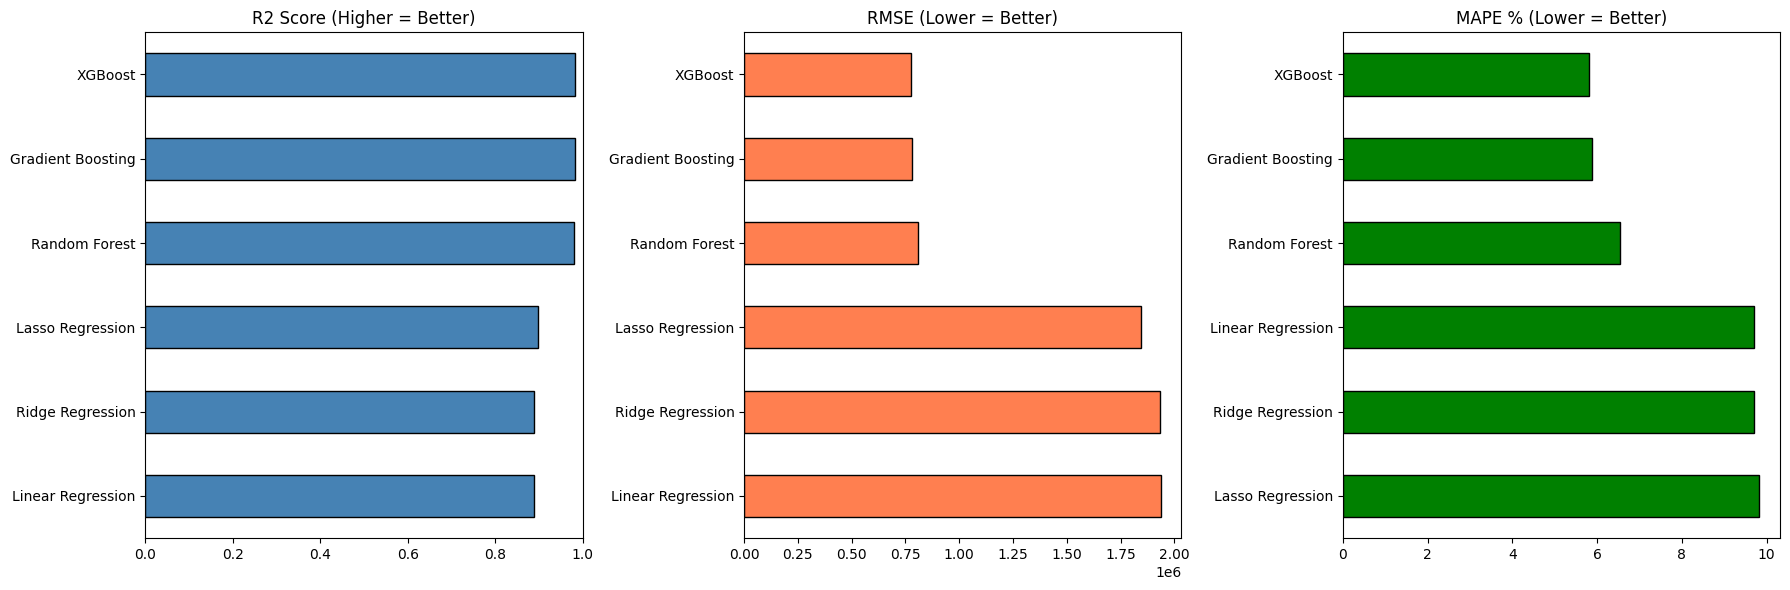

In [15]:
# =============================================
# STEP 13: MODEL COMPARISON VISUALIZATION
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

results_df['R2'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('R2 Score (Higher = Better)')
axes[0].set_xlim(0, 1)

results_df['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('RMSE (Lower = Better)')

results_df['MAPE'].sort_values(ascending=False).plot(kind='barh', ax=axes[2], color='green', edgecolor='black')
axes[2].set_title('MAPE % (Lower = Better)')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# =============================================
# STEP 14: HYPERPARAMETER TUNING (Top 3 Models)
# =============================================
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

# --- XGBoost Tuning ---
print("=" * 60)
print("TUNING XGBoost")
print("=" * 60)

xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid=xgb_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)

start = time.time()
xgb_grid.fit(X_train, y_train)
xgb_time = time.time() - start

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"\nBest Params: {xgb_grid.best_params_}")
print(f"Best CV R2:  {xgb_grid.best_score_:.4f}")
print(f"Test R2:     {r2_score(y_test, xgb_pred):.4f}")
print(f"Test RMSE:   {xgb_rmse:.4f}")
print(f"Test MAE:    {xgb_mae:.4f}")
print(f"Time:        {xgb_time:.1f}s")

TUNING XGBoost
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best CV R2:  0.9869
Test R2:     0.9866
Test RMSE:   0.0676
Test MAE:    0.0568
Time:        64.9s


In [17]:
# --- LightGBM Tuning ---
print("\n" + "=" * 60)
print("TUNING LightGBM")
print("=" * 60)

lgbm_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [5, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'num_leaves': [31, 50]
}

lgbm_grid = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid=lgbm_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)

start = time.time()
lgbm_grid.fit(X_train, y_train)
lgbm_time = time.time() - start

lgbm_best = lgbm_grid.best_estimator_
lgbm_pred = lgbm_best.predict(X_test)

lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)

print(f"\nBest Params: {lgbm_grid.best_params_}")
print(f"Best CV R2:  {lgbm_grid.best_score_:.4f}")
print(f"Test R2:     {r2_score(y_test, lgbm_pred):.4f}")
print(f"Test RMSE:   {lgbm_rmse:.4f}")
print(f"Test MAE:    {lgbm_mae:.4f}")
print(f"Time:        {lgbm_time:.1f}s")


TUNING LightGBM
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'num_leaves': 50, 'subsample': 0.7}
Best CV R2:  0.9867
Test R2:     0.9861
Test RMSE:   0.0687
Test MAE:    0.0572
Time:        66.4s


In [18]:
# --- Gradient Boosting Tuning ---
print("\n" + "=" * 60)
print("TUNING Gradient Boosting")
print("=" * 60)

gb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)

start = time.time()
gb_grid.fit(X_train, y_train)
gb_time = time.time() - start

gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)

print(f"\nBest Params: {gb_grid.best_params_}")
print(f"Best CV R2:  {gb_grid.best_score_:.4f}")
print(f"Test R2:     {r2_score(y_test, gb_pred):.4f}")
print(f"Test RMSE:   {gb_rmse:.4f}")
print(f"Test MAE:    {gb_mae:.4f}")
print(f"Time:        {gb_time:.1f}s")


TUNING Gradient Boosting
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.7}
Best CV R2:  0.9869
Test R2:     0.9862
Test RMSE:   0.0686
Test MAE:    0.0570
Time:        207.9s


In [19]:
# =============================================
# STEP 15: FINAL COMPARISON OF TUNED MODELS
# =============================================
tuned_models = {
    'XGBoost (Tuned)': (xgb_best, xgb_pred),
    'LightGBM (Tuned)': (lgbm_best, lgbm_pred),
    'Gradient Boosting (Tuned)': (gb_best, gb_pred),
}

print("=" * 70)
print("TUNED MODEL COMPARISON (on test set, actual INR scale)")
print("=" * 70)

y_test_actual = np.expm1(y_test)

for name, (model, pred) in tuned_models.items():
    pred_actual = np.expm1(pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
    mae = mean_absolute_error(y_test_actual, pred_actual)
    r2 = r2_score(y_test_actual, pred_actual)
    mape = np.mean(np.abs((y_test_actual - pred_actual) / y_test_actual)) * 100
    print(f"{name:30s} | R2: {r2:.4f} | RMSE: Rs.{rmse:,.0f} | MAE: Rs.{mae:,.0f} | MAPE: {mape:.2f}%")

TUNED MODEL COMPARISON (on test set, actual INR scale)
XGBoost (Tuned)                | R2: 0.9830 | RMSE: Rs.758,051 | MAE: Rs.559,636 | MAPE: 5.69%
LightGBM (Tuned)               | R2: 0.9823 | RMSE: Rs.772,236 | MAE: Rs.564,136 | MAPE: 5.73%
Gradient Boosting (Tuned)      | R2: 0.9828 | RMSE: Rs.762,303 | MAE: Rs.561,069 | MAPE: 5.71%


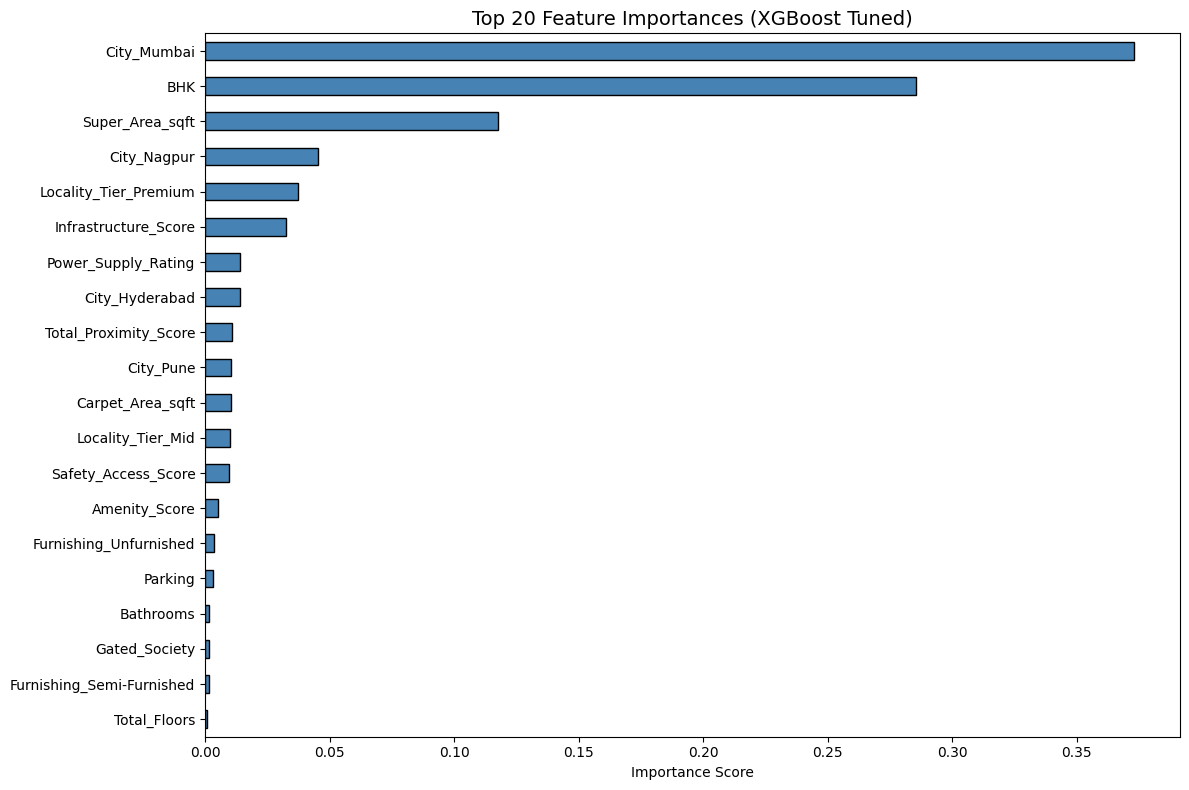


Top 20 Features:
   1. City_Mumbai                         0.3729
   2. BHK                                 0.2855
   3. Super_Area_sqft                     0.1174
   4. City_Nagpur                         0.0454
   5. Locality_Tier_Premium               0.0372
   6. Infrastructure_Score                0.0324
   7. Power_Supply_Rating                 0.0140
   8. City_Hyderabad                      0.0139
   9. Total_Proximity_Score               0.0109
  10. City_Pune                           0.0105
  11. Carpet_Area_sqft                    0.0103
  12. Locality_Tier_Mid                   0.0100
  13. Safety_Access_Score                 0.0096
  14. Amenity_Score                       0.0053
  15. Furnishing_Unfurnished              0.0035
  16. Parking                             0.0031
  17. Bathrooms                           0.0018
  18. Gated_Society                       0.0017
  19. Furnishing_Semi-Furnished           0.0014
  20. Total_Floors                        0.0009


In [20]:
# =============================================
# STEP 16: FEATURE IMPORTANCE (Best Model)
# =============================================
# Use XGBoost as likely best performer
importances = pd.Series(xgb_best.feature_importances_, index=X_train.columns)
top_20 = importances.nlargest(20)

plt.figure(figsize=(12, 8))
top_20.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances (XGBoost Tuned)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 20 Features:")
for i, (feat, imp) in enumerate(top_20.items(), 1):
    print(f"  {i:2d}. {feat:35s} {imp:.4f}")

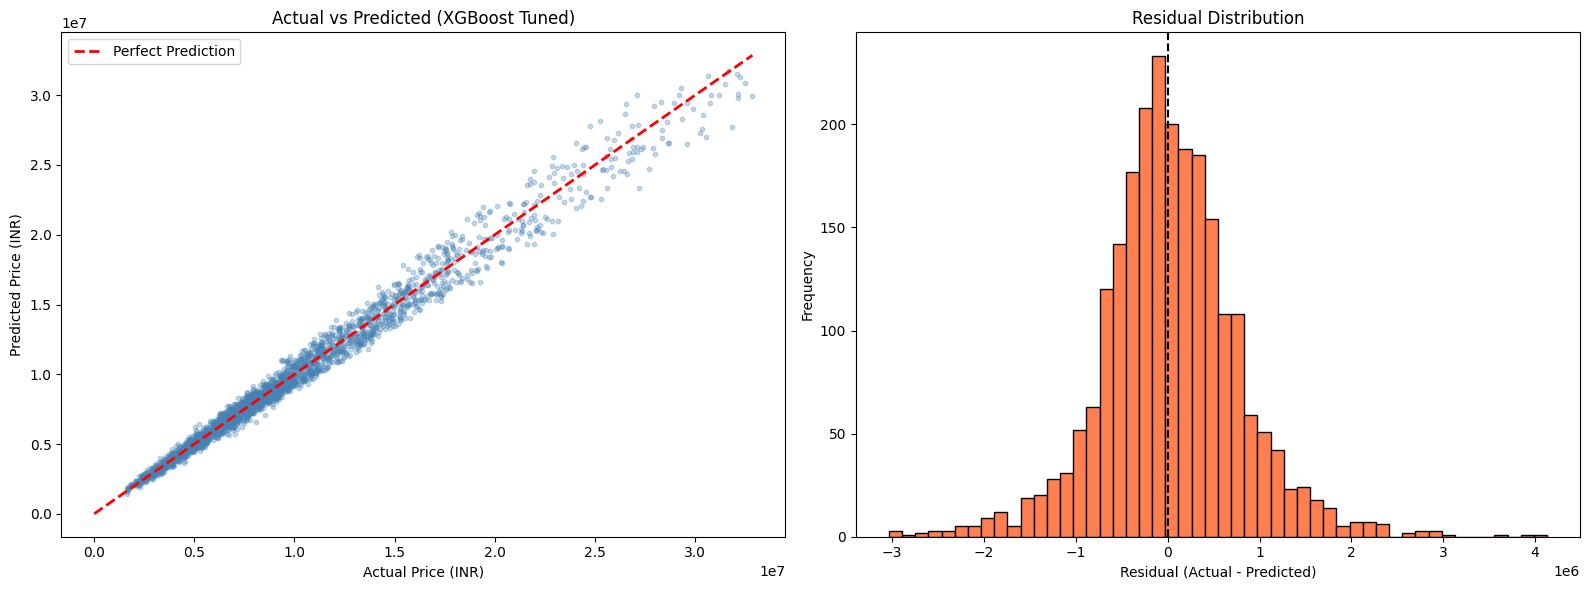

Mean residual:   Rs.32,498
Median residual: Rs.7,145
Std residual:    Rs.757,515


In [21]:
# =============================================
# STEP 17: ACTUAL vs PREDICTED PLOT
# =============================================
best_pred_actual = np.expm1(xgb_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test_actual, best_pred_actual, alpha=0.3, s=10, c='steelblue')
max_val = max(y_test_actual.max(), best_pred_actual.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')
axes[0].set_title('Actual vs Predicted (XGBoost Tuned)')
axes[0].legend()

# Residuals distribution
residuals = y_test_actual - best_pred_actual
axes[1].hist(residuals, bins=50, color='coral', edgecolor='black')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean residual:   Rs.{residuals.mean():,.0f}")
print(f"Median residual: Rs.{residuals.median():,.0f}")
print(f"Std residual:    Rs.{residuals.std():,.0f}")